# 02b — Estadísticas descriptivas por clase
*Caracterización completa de las 9 clases acústicas detectadas.*

Cuatro bloques:
1. **Confianza por clase** — distribución, media, P25/P75 y diferencia por fuente.
2. **Duración de evento** — distribución de `t_end−t_start` por clase.
3. **Tasa de detección** — eventos/min y eventos/km por clase, trayecto y fuente.
4. **Co-ocurrencia** — qué clases aparecen juntas en ventana ±5 s (matriz y red).

> Las clases fuera de dominio se incluyen descriptivamente; el peligro se restringe a Horn(0)+Siren(1) como se argumenta en `02_reliability_and_classes`.

In [2]:
import sys, warnings
sys.path.insert(0, "../scripts")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geo_utils as gu

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.width", 140)

geo = gu.load_geo()
geo = geo[~geo["trayecto"].isin(gu.BAD_TRAYECTOS)].copy()
geo["class_name"] = geo["class"].map(gu.CLASS_NAMES)
geo["duration_s"] = (geo.t_end - geo.t_start).dt.total_seconds()

tracks = gu.load_tracks()
tracks = tracks[~tracks["trayecto"].isin(gu.BAD_TRAYECTOS)].copy()

CLASS_ORDER = [gu.CLASS_NAMES[i] for i in range(9)]
FOCUS_ORDER = ["Horn", "Siren", "Speech"]   # clases de interés principal
ROAD_NAMES  = [gu.CLASS_NAMES[c] for c in gu.ROAD_CLASSES]

print(f"{len(geo):,} detecciones | {geo.trayecto.nunique()} trayectos | fuentes: {geo.source.unique().tolist()}")

13,041 detecciones | 35 trayectos | fuentes: ['mic', 'mobile']


In [3]:
# Paleta consistente clase → color
_pal_list = sns.color_palette("tab10", 9)
CLASS_PALETTE = {gu.CLASS_NAMES[i]: _pal_list[i] for i in range(9)}
DOMAIN_COLOR = {"Vial (peligro)": "#c0392b", "Contexto": "#2980b9", "Fuera de dominio": "#95a5a6"}
def domain_color(name):
    if name in ("Horn","Siren"):     return DOMAIN_COLOR["Vial (peligro)"]
    if name == "Speech":             return DOMAIN_COLOR["Contexto"]
    return DOMAIN_COLOR["Fuera de dominio"]

## 0 — Distribución global de clases (sin filtrar vs filtradas)

Comparación directa de las 9 clases antes y después de aplicar el umbral de confianza dinámico (media + 1·DE por clase).

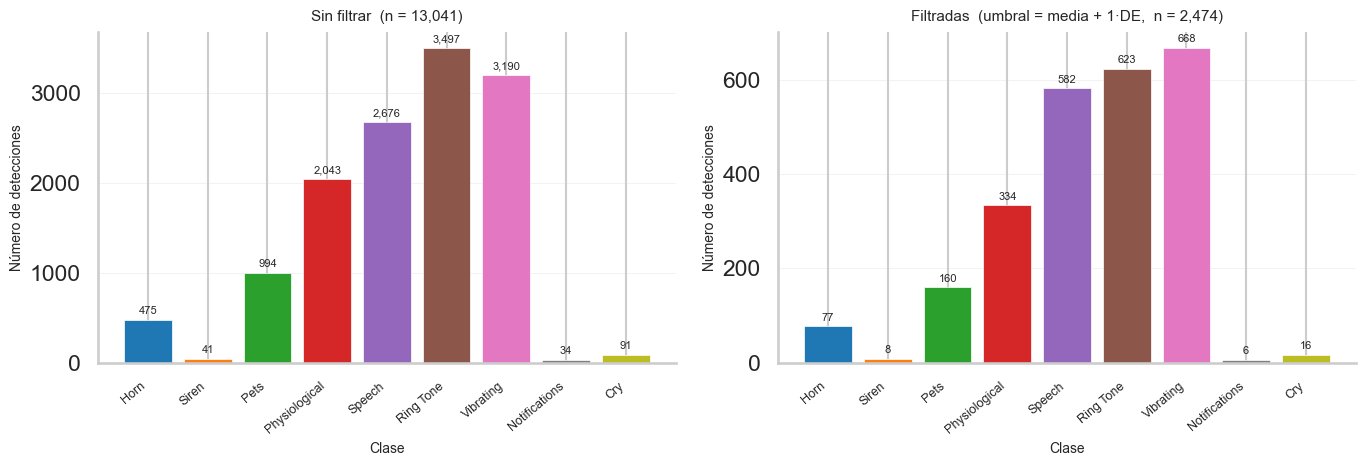

Saved: outputs/class_distribution_sidebyside.png


In [4]:
# 0 — Distribución global de clases (sin filtrar vs filtradas)
# Umbral dinámico: media + 1·DE por clase
thr = geo.groupby("class_name")["confidence"].transform(lambda x: x.mean() + x.std())
geo_filt = geo[geo["confidence"] >= thr]

counts_all  = geo["class_name"].value_counts().reindex(CLASS_ORDER, fill_value=0)
counts_filt = geo_filt["class_name"].value_counts().reindex(CLASS_ORDER, fill_value=0)
colors_bar  = [CLASS_PALETTE[c] for c in CLASS_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.subplots_adjust(wspace=0.38)

for ax, counts, title in [
    (axes[0], counts_all,  f"Sin filtrar  (n = {len(geo):,})"),
    (axes[1], counts_filt, f"Filtradas  (umbral = media + 1·DE,  n = {len(geo_filt):,})"),
]:
    bars = ax.bar(CLASS_ORDER, counts.values, color=colors_bar, edgecolor="white", linewidth=0.5)
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel("Clase", fontsize=10)
    ax.set_ylabel("Número de detecciones", fontsize=10)
    ax.set_xticks(range(len(CLASS_ORDER)))
    ax.set_xticklabels(CLASS_ORDER, rotation=40, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3, linewidth=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(bars, counts.values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + counts.values.max() * 0.012,
                    f"{int(val):,}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/class_distribution_sidebyside.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: outputs/class_distribution_sidebyside.png")

## 1 — Confianza por clase
¿El modelo asigna confianzas similares a todas las clases o hay clases sistemáticamente más inciertas? Diferencias entre `mic` y `mobile`.

In [5]:
# 1a — Tabla resumen de confianza por clase
conf_tab = (geo.groupby("class_name")["confidence"]
              .agg(n="count", mean="mean", std="std",
                   p25=lambda s: s.quantile(.25),
                   median="median",
                   p75=lambda s: s.quantile(.75))
              .loc[CLASS_ORDER].round(3))
display(conf_tab)

,n,mean,std,p25,median,p75
class_name,,,,,,
Horn,475,0.292,0.202,0.139,0.206,0.403
Siren,41,0.325,0.196,0.157,0.274,0.479
Pets,994,0.256,0.163,0.133,0.193,0.323
Physiological,2043,0.276,0.176,0.142,0.214,0.360
Speech,2676,0.476,0.258,0.221,0.471,0.713
Ring Tone,3497,0.324,0.179,0.172,0.281,0.443
Vibrating,3190,0.385,0.247,0.167,0.309,0.570
Notifications,34,0.283,0.186,0.129,0.229,0.397
Cry,91,0.256,0.138,0.139,0.218,0.352


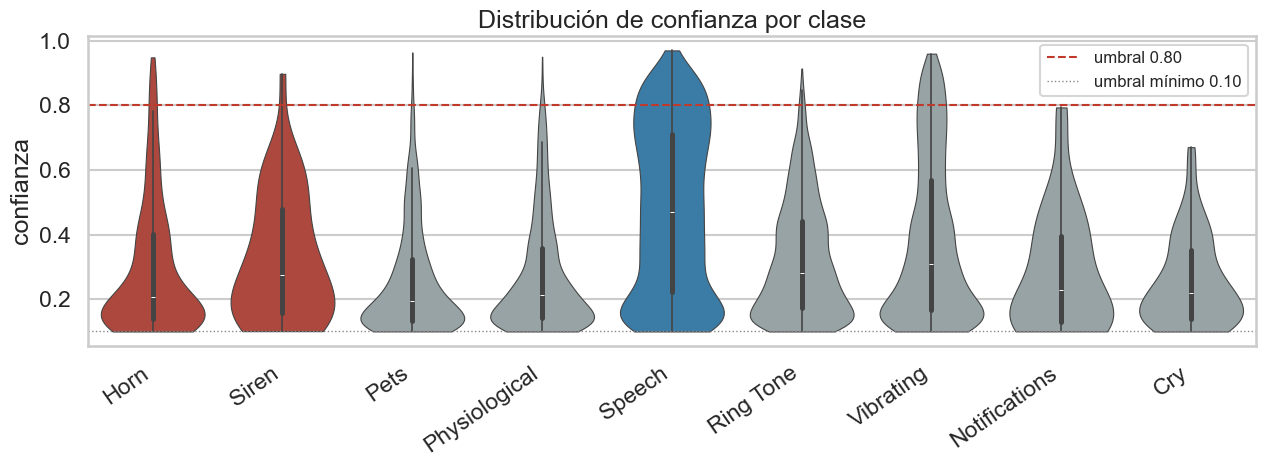

In [6]:
# 1b — Violines de confianza por clase (todas, color=dominio)
fig, ax = plt.subplots(figsize=(13, 5))
palette_class = {n: domain_color(n) for n in CLASS_ORDER}
vio = sns.violinplot(data=geo, x="class_name", y="confidence",
                     order=CLASS_ORDER, palette=palette_class, cut=0, ax=ax, linewidth=.8)
ax.axhline(0.80, color="#c0392b", ls="--", lw=1.5, label="umbral 0.80")
ax.axhline(0.10, color="#888", ls=":", lw=1,   label="umbral mínimo 0.10")
ax.set_title("Distribución de confianza por clase"); ax.set_xlabel("")
ax.set_ylabel("confianza"); ax.legend(fontsize=12)
plt.xticks(rotation=35, ha="right"); plt.tight_layout()
plt.savefig("../outputs/stat_conf_violin.png", dpi=130, bbox_inches="tight"); plt.show()

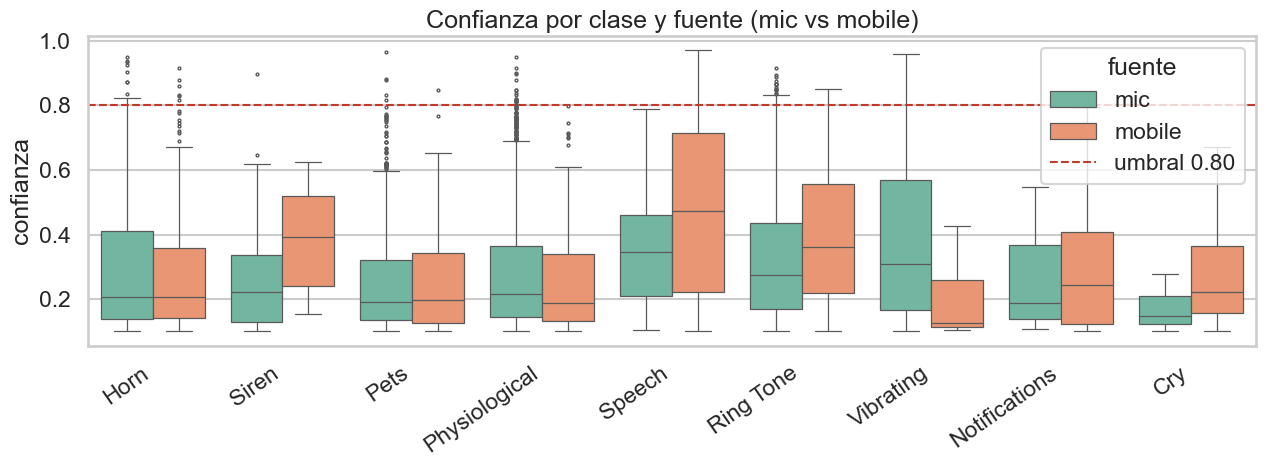

In [7]:
# 1c — Confianza por clase y fuente (strip + box)
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=geo, x="class_name", y="confidence", hue="source",
            order=CLASS_ORDER, palette="Set2", ax=ax, linewidth=.9, fliersize=2)
ax.axhline(0.80, color="#c0392b", ls="--", lw=1.5, label="umbral 0.80")
ax.set_title("Confianza por clase y fuente (mic vs mobile)")
ax.set_xlabel(""); ax.set_ylabel("confianza"); ax.legend(title="fuente")
plt.xticks(rotation=35, ha="right"); plt.tight_layout()
plt.savefig("../outputs/stat_conf_by_source.png", dpi=130, bbox_inches="tight"); plt.show()

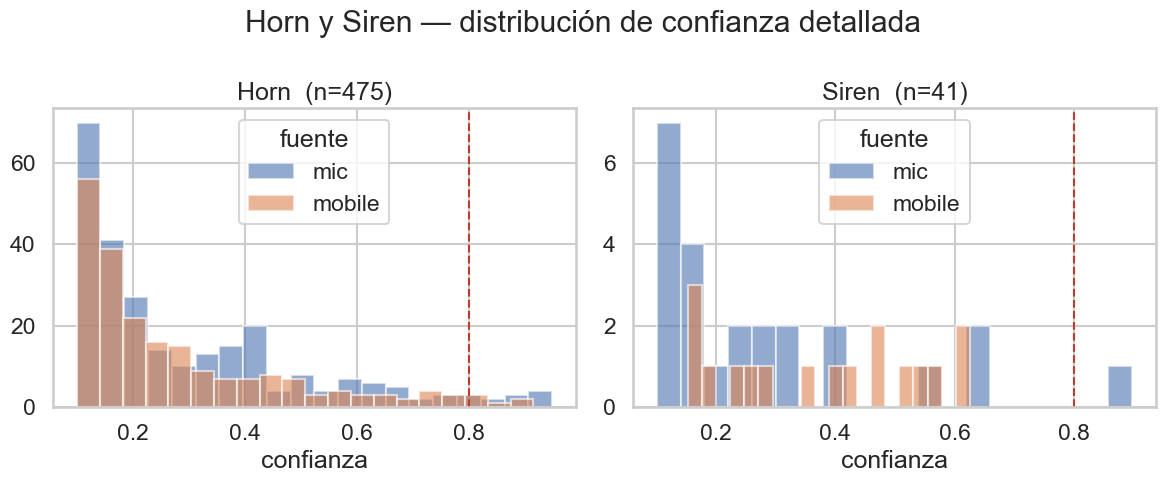

In [8]:
# 1d — Distribución de confianza Horn+Siren (las que importan)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
for ax, cid in zip(axes, [0, 1]):
    sub = geo[geo["class"] == cid]
    for src, grp in sub.groupby("source"):
        ax.hist(grp.confidence, bins=20, alpha=.6, label=src, edgecolor="white")
    ax.axvline(0.80, color="#c0392b", ls="--", lw=1.5)
    ax.set_title(f"{gu.CLASS_NAMES[cid]}  (n={len(sub)})")
    ax.set_xlabel("confianza"); ax.legend(title="fuente")
plt.suptitle("Horn y Siren — distribución de confianza detallada")
plt.tight_layout(); plt.savefig("../outputs/stat_conf_horn_siren.png", dpi=130, bbox_inches="tight"); plt.show()

**Lectura.** Clases con confianza sistemáticamente alta pueden estar sobredispararando (modelo muy seguro en OOD). Horn y Siren con confianza muy baja y skewed → umbral 0.80 deja muy pocos eventos (ver NB-02 sensibilidad). Diferencias mic/mobile revelan sesgo de sensor.

## 2 — Duración de evento por clase
Cada detección tiene un intervalo temporal [`t_start`, `t_end`] ≤ 7.5 s (tamaño del chunk). La duración refleja cuánto tiempo el modelo sostiene la detección dentro del espectrograma.

In [9]:
dur_tab = (geo.groupby("class_name")["duration_s"]
              .agg(n="count", mean="mean", std="std",
                   p25=lambda s: s.quantile(.25),
                   median="median",
                   p75=lambda s: s.quantile(.75),
                   max="max")
              .loc[CLASS_ORDER].round(3))
display(dur_tab)

,n,mean,std,p25,median,p75,max
class_name,,,,,,,
Horn,475,2.391,1.702,0.747,2.299,3.704,7.624
Siren,41,4.001,2.928,1.424,2.238,7.547,7.643
Pets,994,1.016,1.370,0.233,0.346,0.837,7.619
Physiological,2043,1.659,1.535,0.238,1.120,3.184,7.644
Speech,2676,5.921,2.234,4.393,7.353,7.613,7.660
Ring Tone,3497,6.310,1.565,5.578,7.024,7.562,7.654
Vibrating,3190,1.945,0.583,1.521,2.064,2.415,2.898
Notifications,34,1.014,1.148,0.448,0.548,0.602,3.811
Cry,91,5.955,1.603,4.956,6.338,7.369,7.635


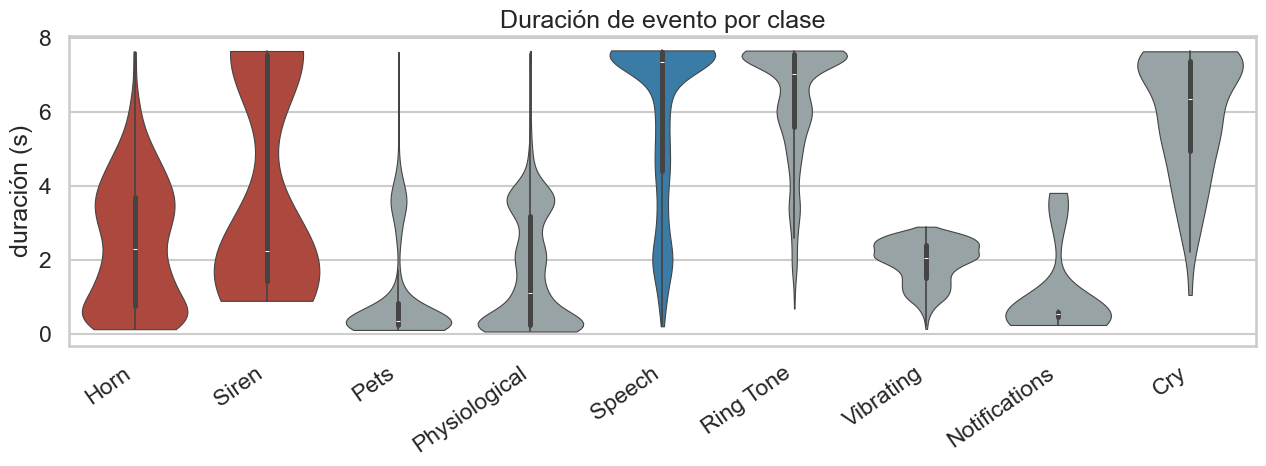

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.violinplot(data=geo, x="class_name", y="duration_s",
               order=CLASS_ORDER, palette=palette_class, cut=0, ax=ax, linewidth=.8)
ax.set_title("Duración de evento por clase"); ax.set_xlabel(""); ax.set_ylabel("duración (s)")
plt.xticks(rotation=35, ha="right"); plt.tight_layout()
plt.savefig("../outputs/stat_duration_violin.png", dpi=130, bbox_inches="tight"); plt.show()

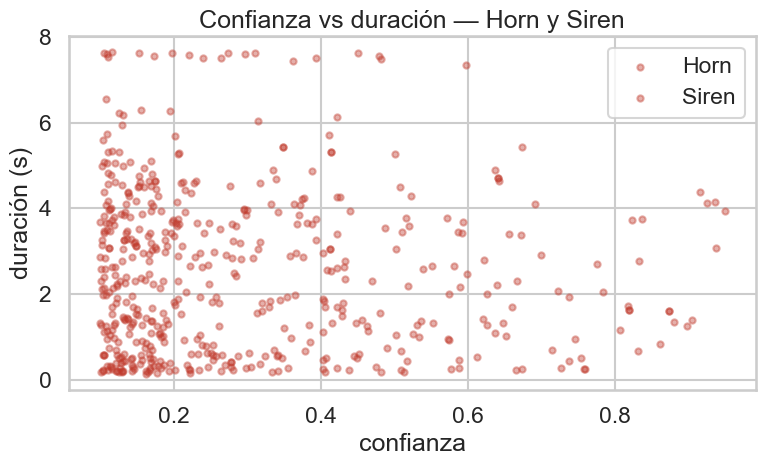

Horn: Spearman r=-0.044  p=0.3422  n=475
Siren: Spearman r=-0.325  p=0.0379  n=41


In [11]:
# Duración vs confianza (scatter Horn+Siren — buscar correlación)
fig, ax = plt.subplots(figsize=(8, 5))
for cid in [0, 1]:
    sub = geo[geo["class"] == cid]
    ax.scatter(sub.confidence, sub.duration_s, alpha=.4, s=20,
               label=gu.CLASS_NAMES[cid], color=domain_color(gu.CLASS_NAMES[cid]))
ax.set_xlabel("confianza"); ax.set_ylabel("duración (s)")
ax.set_title("Confianza vs duración — Horn y Siren")
ax.legend(); plt.tight_layout()
plt.savefig("../outputs/stat_conf_vs_duration.png", dpi=130, bbox_inches="tight"); plt.show()
# Correlación de Spearman (no asume normalidad)
from scipy.stats import spearmanr
for cid in [0, 1]:
    sub = geo[geo["class"] == cid].dropna(subset=["confidence","duration_s"])
    r, p = spearmanr(sub.confidence, sub.duration_s)
    print(f"{gu.CLASS_NAMES[cid]}: Spearman r={r:.3f}  p={p:.4f}  n={len(sub)}")

**Lectura.** Duración corta + baja confianza en Horn/Siren → pueden ser eventos reales breves (bocinazo corto) o FP. Una correlación positiva confianza↔duración sugiere que las detecciones más largas son más fiables (el modelo 've' el evento en más frames del espectrograma).

## 3 — Tasa de detección: eventos/min y eventos/km
Normaliza el recuento de detecciones por el tiempo grabado y la distancia recorrida en cada trayecto. Permite comparar trayectos de distinta longitud y duración.

In [12]:
# Duración por trayecto (min)
dur_tr = (geo.groupby("trayecto")
             .agg(t0=("t_start","min"), t1=("t_start","max"))
             .assign(minutes=lambda d:(d.t1-d.t0).dt.total_seconds()/60)
             ["minutes"])

# Distancia por trayecto (km) — haversine acumulada sobre trackpoints
import sys; sys.path.insert(0, "../scripts") if "../scripts" not in sys.path else None
from geo_utils import haversine_m
dist_rows = []
for tr, grp in tracks.sort_values(["trayecto","time"]).groupby("trayecto"):
    lats, lons = grp.lat.values, grp.lon.values
    d = haversine_m(lats[:-1], lons[:-1], lats[1:], lons[1:]).sum() / 1000
    dist_rows.append({"trayecto": tr, "km": d})
dist_tr = pd.DataFrame(dist_rows).set_index("trayecto")["km"]
print("Distancia media por trayecto:", round(dist_tr.mean(),2), "km")

Distancia media por trayecto: 12.74 km


In [13]:
# Tasa por clase y trayecto
rate_rows = []
for (tr, cn), grp in geo.groupby(["trayecto","class_name"]):
    n = len(grp)
    mins = dur_tr.get(tr, np.nan)
    km   = dist_tr.get(tr, np.nan)
    rate_rows.append({"trayecto": tr, "class_name": cn, "n": n,
                      "per_min": n/mins if mins else np.nan,
                      "per_km":  n/km   if km   else np.nan,
                      "source": grp.source.iloc[0]})
rates = pd.DataFrame(rate_rows)

# Resumen por clase
rate_sum = (rates.groupby("class_name")[["per_min","per_km"]]
                 .agg(["mean","std"]).loc[CLASS_ORDER].round(3))
display(rate_sum)

per_min         per_km        
                 mean    std    mean     std
class_name                                  
Horn            0.723  0.647   1.050   0.993
Siren           0.115  0.065   0.165   0.117
Pets            1.570  1.212   2.203   1.710
Physiological   3.279  3.083   4.508   4.250
Speech          7.345  5.295  11.171   8.255
Ring Tone       5.848  5.082   7.691   6.472
Vibrating       7.162  7.446   9.735  10.572
Notifications   0.117  0.066   0.175   0.117
Cry             0.312  0.342   0.461   0.524

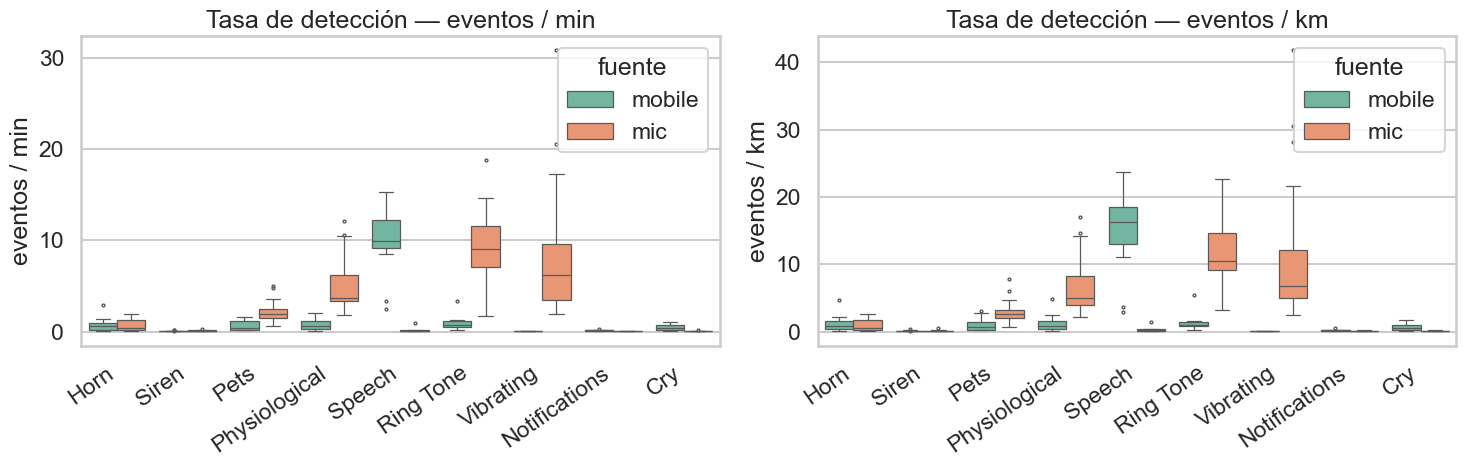

In [14]:
# Boxplot eventos/min por clase
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col, ylabel in zip(axes, ["per_min","per_km"], ["eventos / min","eventos / km"]):
    sns.boxplot(data=rates, x="class_name", y=col, hue="source",
                order=CLASS_ORDER, palette="Set2", ax=ax, linewidth=.9, fliersize=2)
    ax.set_title(f"Tasa de detección — {ylabel}"); ax.set_xlabel(""); ax.set_ylabel(ylabel)
    ax.legend(title="fuente"); plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
plt.tight_layout()
plt.savefig("../outputs/stat_rate_per_class.png", dpi=130, bbox_inches="tight"); plt.show()

In [15]:
# Top-10 trayectos por tasa de Horn+Siren combinada (/km)
top = (rates[rates.class_name.isin(ROAD_NAMES)]
         .groupby(["trayecto","source"])["per_km"].sum()
         .reset_index().sort_values("per_km", ascending=False).head(10))
display(top)

,trayecto,source,per_km
34,SILLA-PAIPORTA_1,mobile,4.913957
28,PAIPORTA-MALVARROSA,mobile,2.677431
21,PAIPORTA-ETSE_4,mic,2.627917
25,PAIPORTA-ETSE_8,mic,2.595587
22,PAIPORTA-ETSE_5,mic,2.319525
14,GYM-PAIPORTA,mobile,2.067369
7,ETSE-PAIPORTA_3,mic,1.898509
9,ETSE-PAIPORTA_5,mic,1.881909
3,ETSE-PAIPORTA_1,mic,1.769830
27,PAIPORTA-GYM,mobile,1.651063


**Lectura.** Tasa alta de Horn/km en ciertos trayectos identifica corredores más conflictivos independientemente de su longitud. Diferencia mic/mobile en tasa → sesgo de sensor cuantificado.

## 4 — Co-ocurrencia entre clases (ventana ±5 s)
Dos detecciones co-ocurren si sus ventanas temporales se solapan ± 5 s dentro del mismo trayecto. La matriz muestra con qué frecuencia cada par de clases aparece simultáneamente.

In [16]:
WINDOW_S = 5.0
pairs = []
for tr, grp in geo.groupby("trayecto"):
    grp = grp.sort_values("t_start").reset_index(drop=True)
    ts  = grp.t_start.values.astype("datetime64[us]").astype(np.int64) / 1e6  # → segundos float
    cls = grp["class"].values
    for i in range(len(grp)):
        for j in range(i+1, len(grp)):
            if abs(ts[j] - ts[i]) > WINDOW_S:
                break
            pairs.append((cls[i], cls[j]))
            pairs.append((cls[j], cls[i]))
print(f"{len(pairs)//2:,} pares co-ocurrentes en ventana ±{WINDOW_S}s")

39,744 pares co-ocurrentes en ventana ±5.0s


In [17]:
# Matriz de co-ocurrencia (conteo)
comat = np.zeros((9, 9), dtype=int)
for a, b in pairs:
    comat[int(a), int(b)] += 1
np.fill_diagonal(comat, 0)   # diagonal = auto-co-ocurrencia: excluir

labels_9 = [gu.CLASS_NAMES[i] for i in range(9)]
codf = pd.DataFrame(comat, index=labels_9, columns=labels_9)
display(codf)

,Horn,Siren,Pets,Physiological,Speech,Ring Tone,Vibrating,Notifications,Cry
Horn,0,14,240,355,468,301,710,8,30
Siren,14,0,14,53,28,62,22,0,3
Pets,240,14,0,1386,378,1119,1478,8,24
Physiological,355,53,1386,0,389,3010,3693,17,37
Speech,468,28,378,389,0,280,49,50,106
Ring Tone,301,62,1119,3010,280,0,5540,13,35
Vibrating,710,22,1478,3693,49,5540,0,33,14
Notifications,8,0,8,17,50,13,33,0,1
Cry,30,3,24,37,106,35,14,1,0


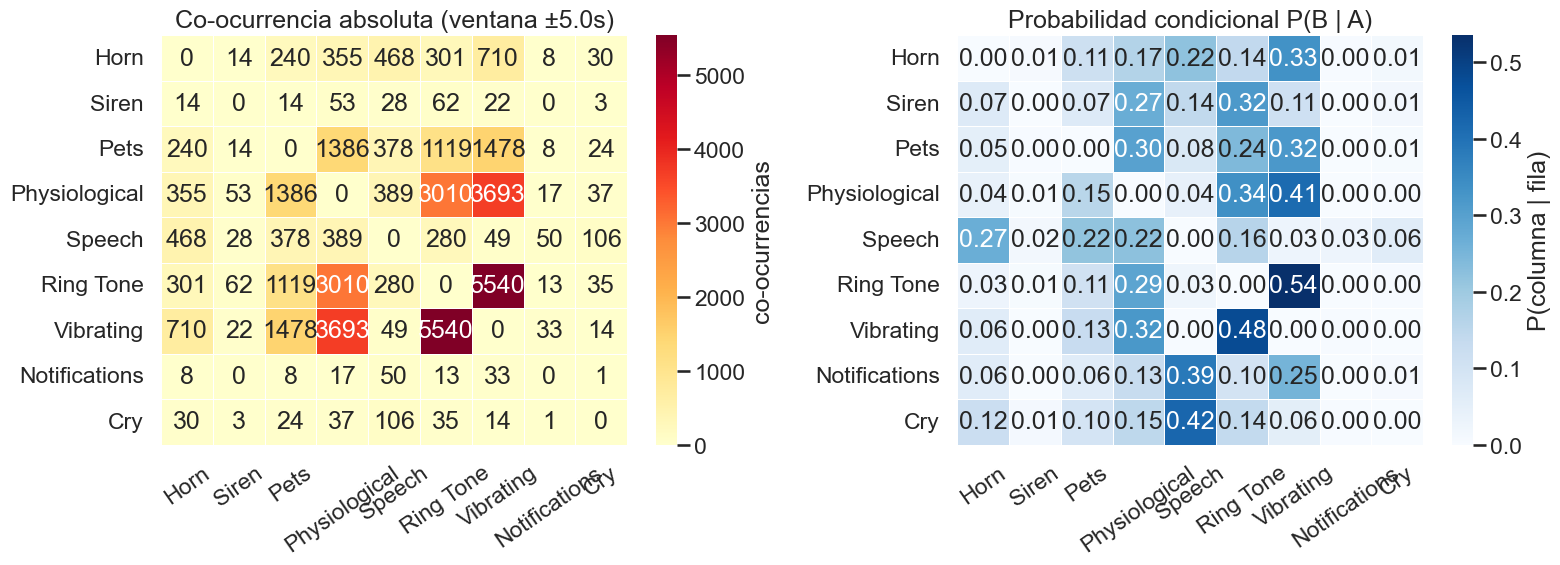

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Matriz absoluta
sns.heatmap(codf, annot=True, fmt="d", cmap="YlOrRd", linewidths=.4,
            ax=axes[0], cbar_kws={"label":"co-ocurrencias"})
axes[0].set_title(f"Co-ocurrencia absoluta (ventana ±{WINDOW_S}s)")

# Normalizada por mínimo de la fila (P(B|A))
codf_norm = codf.div(codf.sum(axis=1).replace(0, np.nan), axis=0).fillna(0).round(3)
sns.heatmap(codf_norm, annot=True, fmt=".2f", cmap="Blues", linewidths=.4,
            ax=axes[1], cbar_kws={"label":"P(columna | fila)"})
axes[1].set_title("Probabilidad condicional P(B | A)")
for ax in axes: ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig("../outputs/stat_cooccurrence.png", dpi=130, bbox_inches="tight"); plt.show()

In [19]:
# Co-ocurrencia solo para Horn y Siren (vista de peligro)
print("Cuando se detecta Horn, ¿qué clase co-ocurre más?")
horn_row = codf.loc["Horn"].sort_values(ascending=False)
print(horn_row.head(5).to_string())
print()
print("Cuando se detecta Siren:")
if "Siren" in codf.index and codf.loc["Siren"].sum() > 0:
    siren_row = codf.loc["Siren"].sort_values(ascending=False)
    print(siren_row.head(5).to_string())
else:
    print("Siren con pocos eventos co-ocurrentes (n=19 total)")

Cuando se detecta Horn, ¿qué clase co-ocurre más?
Vibrating        710
Speech           468
Physiological    355
Ring Tone        301
Pets             240

Cuando se detecta Siren:
Ring Tone        62
Physiological    53
Speech           28
Vibrating        22
Horn             14


**Lectura.** Co-ocurrencia de Horn con Speech es esperable (tráfico + radio). Co-ocurrencia Horn+Siren —aunque Siren es escasa— marca momentos de emergencia real. Alta co-ocurrencia de clases OOD entre sí (p.ej. Vibrating + Ring Tone) puede indicar artefactos del modelo (activaciones correladas en el mismo chunk ruidoso).

## 5 — Exposición a Speech: % tiempo activo y densidad (mic vs mobile)

Speech es la única clase-cabina que funciona como señal directa de conversación / distracción del conductor.
Esta sección cuantifica la **exposición temporal** (no el conteo de eventos):

- **`speech_pct`** = segundos con Speech activo (unión de intervalos) / duración GPS del trayecto × 100.
- **`speech_per_min`** = nº detecciones Speech / duración GPS del trayecto (min).

Comparación **mic (conductor solo)** vs **mobile (conductor acompañado)**.

> ⚠️ Confound de sensor declarado: mic (2 micrófonos, nr=0.85, ruta fija PAIPORTA-ETSE) vs mobile (1 mic, nr=0.50, rutas variadas). Diferencias no son atribuibles exclusivamente a la presencia de acompañante.

=== Exposición a Speech por fuente ===


speech_pct               speech_per_min              n_speech               
             mean median    std           mean median   std     mean median     std
source                                                                             
mic          0.15    0.0   0.45           0.07    0.0  0.20     1.43    0.0    4.23
mobile      62.62   70.9  21.23           9.74    9.8  3.64   189.00  142.0  130.42

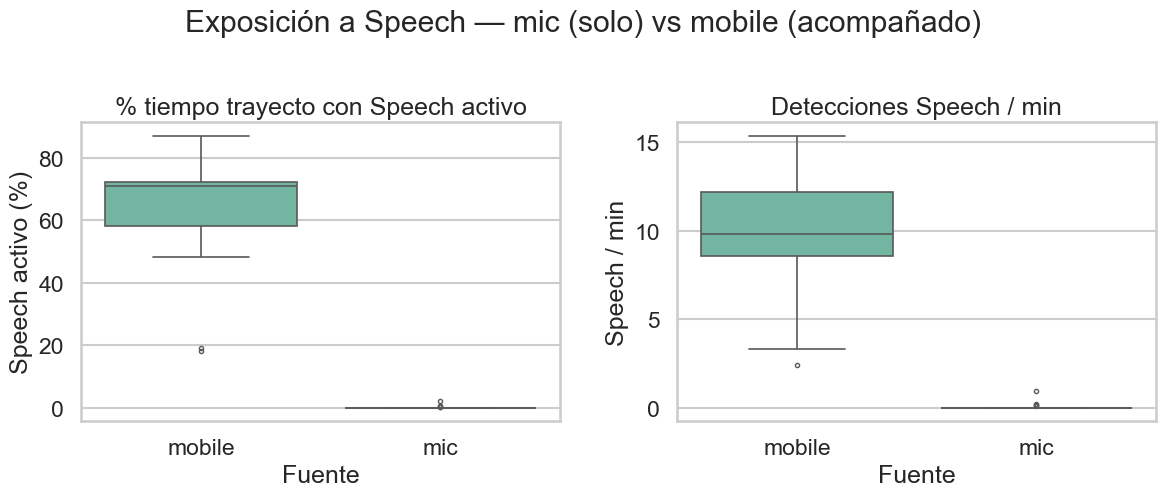

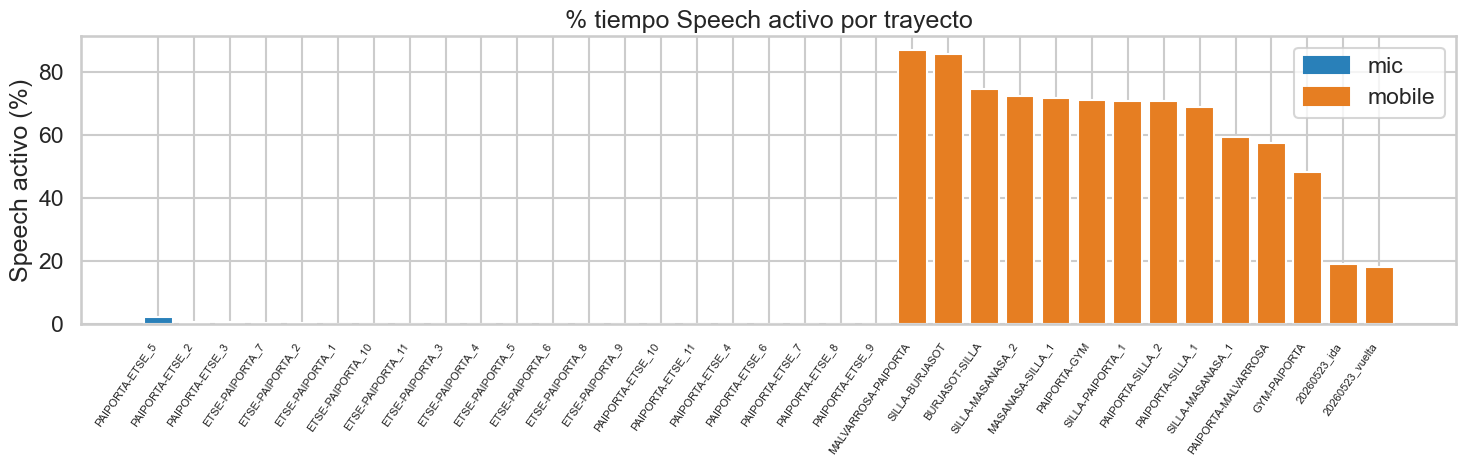


Confound declarado: diferencias mic/mobile reflejan sensor (2 mics, nr, rutas) además del acompañante.


In [20]:
SPEECH_ID = 4  # class id for Speech

def _union_s(df_sub):
    """Total active seconds (union of overlapping [t_start, t_end] intervals)."""
    if df_sub.empty:
        return 0.0
    t0 = df_sub.t_start.values.astype("datetime64[us]").astype(np.int64)
    t1 = df_sub.t_end.values.astype("datetime64[us]").astype(np.int64)
    ivs = sorted(zip(t0, t1))
    merged = [list(ivs[0])]
    for s, e in ivs[1:]:
        if s <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return sum(e - s for s, e in merged) / 1e6  # µs → s

# Duración GPS por trayecto (primer a ultimo trackpoint)
gps_dur_s = (
    tracks.groupby("trayecto")["time"]
    .agg(lambda x: (x.max() - x.min()).total_seconds())
)

rows = []
for tr, grp_tr in geo.groupby("trayecto"):
    gps_s = gps_dur_s.get(tr, np.nan)
    speech_tr = grp_tr[grp_tr["class"] == SPEECH_ID]
    speech_s = _union_s(speech_tr)
    n_sp = len(speech_tr)
    rows.append({
        "trayecto":       tr,
        "source":         grp_tr.source.iloc[0],
        "gps_dur_min":    round(gps_s / 60, 1) if pd.notna(gps_s) else np.nan,
        "speech_active_s": round(speech_s, 1),
        "speech_pct":     round(speech_s / gps_s * 100, 1) if gps_s else np.nan,
        "speech_per_min": round(n_sp / (gps_s / 60), 2)   if gps_s else np.nan,
        "n_speech":       n_sp,
    })

speech_df = pd.DataFrame(rows)

# ── Tabla resumen por fuente ─────────────────────────────────────────────────
print("=== Exposición a Speech por fuente ===")
summ = (speech_df.groupby("source")[["speech_pct", "speech_per_min", "n_speech"]]
        .agg(["mean", "median", "std"]).round(2))
display(summ)

# ── Figura: boxplot speech_pct y speech_per_min (mic vs mobile) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=speech_df, x="source", y="speech_pct",
            palette="Set2", ax=axes[0], linewidth=1.2, fliersize=3)
axes[0].set_title("% tiempo trayecto con Speech activo")
axes[0].set_xlabel("Fuente"); axes[0].set_ylabel("Speech activo (%)")

sns.boxplot(data=speech_df, x="source", y="speech_per_min",
            palette="Set2", ax=axes[1], linewidth=1.2, fliersize=3)
axes[1].set_title("Detecciones Speech / min")
axes[1].set_xlabel("Fuente"); axes[1].set_ylabel("Speech / min")

plt.suptitle("Exposición a Speech — mic (solo) vs mobile (acompañado)", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/stat_speech_exposure.png", dpi=130, bbox_inches="tight"); plt.show()

# ── Figura: barras por trayecto (ordenado por fuente y speech_pct) ───────────
sp_sorted = speech_df.sort_values(["source", "speech_pct"], ascending=[True, False])
colors = sp_sorted.source.map({"mic": "#2980b9", "mobile": "#e67e22"})
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(range(len(sp_sorted)), sp_sorted.speech_pct, color=colors, edgecolor="white")
ax.set_xticks(range(len(sp_sorted)))
ax.set_xticklabels(sp_sorted.trayecto, rotation=55, ha="right", fontsize=8)
ax.set_ylabel("Speech activo (%)"); ax.set_xlabel("")
ax.set_title("% tiempo Speech activo por trayecto")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2980b9", label="mic"), Patch(color="#e67e22", label="mobile")])
plt.tight_layout()
plt.savefig("../outputs/stat_speech_exposure_by_traj.png", dpi=130, bbox_inches="tight"); plt.show()

print("\nConfound declarado: diferencias mic/mobile reflejan sensor (2 mics, nr, rutas) además del acompañante.")

=== Índice de distracción (unión todas clases-cabina) ===


dist_pct               dist_per_min              
           mean median    std         mean median    std
source                                                  
mic       50.90  54.00  12.69        23.89  19.45  12.59
mobile    69.07  73.15  19.72        12.50  11.52   4.06


Speech representa de media el 36% del tiempo de distracción total


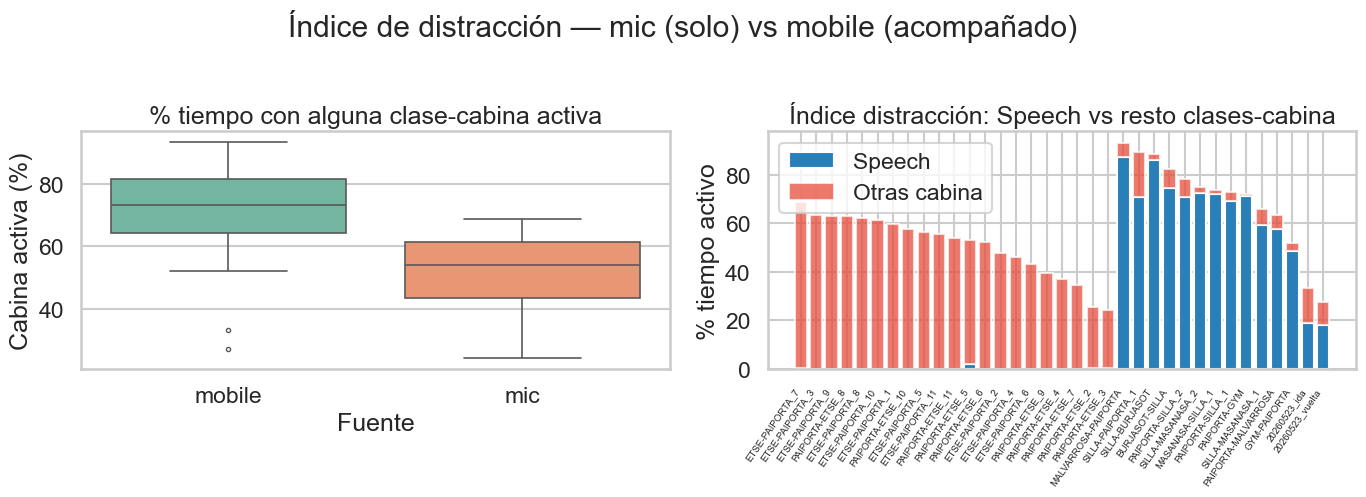

In [21]:
# Índice de distracción genérico — unión de TODAS las clases-cabina
# Cabin: Pets(2), Physiological(3), Speech(4), Ring Tone(5), Vibrating(6), Notifications(7), Cry(8)
CABIN_IDS = {2, 3, 4, 5, 6, 7, 8}

rows_dist = []
for tr, grp_tr in geo.groupby("trayecto"):
    gps_s = gps_dur_s.get(tr, np.nan)
    cabin_tr = grp_tr[grp_tr["class"].isin(CABIN_IDS)]
    dist_s = _union_s(cabin_tr)
    n_cabin = len(cabin_tr)
    sp_pct = speech_df.loc[speech_df.trayecto == tr, "speech_pct"].values
    rows_dist.append({
        "trayecto":      tr,
        "source":        grp_tr.source.iloc[0],
        "gps_dur_min":   round(gps_s / 60, 1) if pd.notna(gps_s) else np.nan,
        "dist_active_s": round(dist_s, 1),
        "dist_pct":      round(dist_s / gps_s * 100, 1) if gps_s else np.nan,
        "dist_per_min":  round(n_cabin / (gps_s / 60), 2) if gps_s else np.nan,
        "n_cabin":       n_cabin,
        "speech_pct":    float(sp_pct[0]) if len(sp_pct) else np.nan,
    })

distract_df = pd.DataFrame(rows_dist)

print("=== Índice de distracción (unión todas clases-cabina) ===")
summ_dist = (distract_df.groupby("source")[["dist_pct", "dist_per_min"]]
             .agg(["mean", "median", "std"]).round(2))
display(summ_dist)

frac_speech = (distract_df["speech_pct"] / distract_df["dist_pct"]).mean() * 100
print(f"\nSpeech representa de media el {frac_speech:.0f}% del tiempo de distracción total")

# Boxplot dist_pct mic vs mobile
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=distract_df, x="source", y="dist_pct",
            palette="Set2", ax=axes[0], linewidth=1.2, fliersize=3)
axes[0].set_title("% tiempo con alguna clase-cabina activa")
axes[0].set_xlabel("Fuente"); axes[0].set_ylabel("Cabina activa (%)")

# Barras apiladas: Speech vs otras cabina por trayecto
comp = distract_df.sort_values(["source", "dist_pct"], ascending=[True, False]).copy()
comp["other_pct"] = (comp["dist_pct"] - comp["speech_pct"].fillna(0)).clip(lower=0)
xp = range(len(comp))
axes[1].bar(xp, comp["speech_pct"].fillna(0), label="Speech", color="#2980b9")
axes[1].bar(xp, comp["other_pct"], bottom=comp["speech_pct"].fillna(0),
            label="Otras cabina", color="#e74c3c", alpha=0.75)
axes[1].set_xticks(xp)
axes[1].set_xticklabels(comp["trayecto"], rotation=55, ha="right", fontsize=7)
axes[1].set_ylabel("% tiempo activo")
axes[1].set_title("Índice distracción: Speech vs resto clases-cabina")
axes[1].legend()
plt.suptitle("Índice de distracción — mic (solo) vs mobile (acompañado)", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/stat_distraction_index.png", dpi=130, bbox_inches="tight"); plt.show()

## 6 — Bloque D: Speech ↔ Ring Tone (artefacto del detector)

El filtro Wiener induce activaciones en la banda de voz que pueden disparar simultáneamente Speech **y** Ring Tone.
Tres métricas para cuantificar este artefacto:

1. **IoU temporal** Speech ∩ Ring Tone dentro del mismo trayecto (solapamiento real de intervalos).
2. **Asimetría** — ¿Ring Tone cae *dentro* de la ventana de Speech? (Ring Tone contenido en Speech → artefacto).
3. **Confianza comparada** — confianza de Ring Tone cuando co-ocurre con Speech vs cuando aparece sola.

Ring Tone total: 3497
  Co-ocurre con Speech  : 0 (0.0%)
  Contenido dentro Speech: 0 (0.0%)

  IoU medio (co-ocurrentes): nan  | mediana: nan


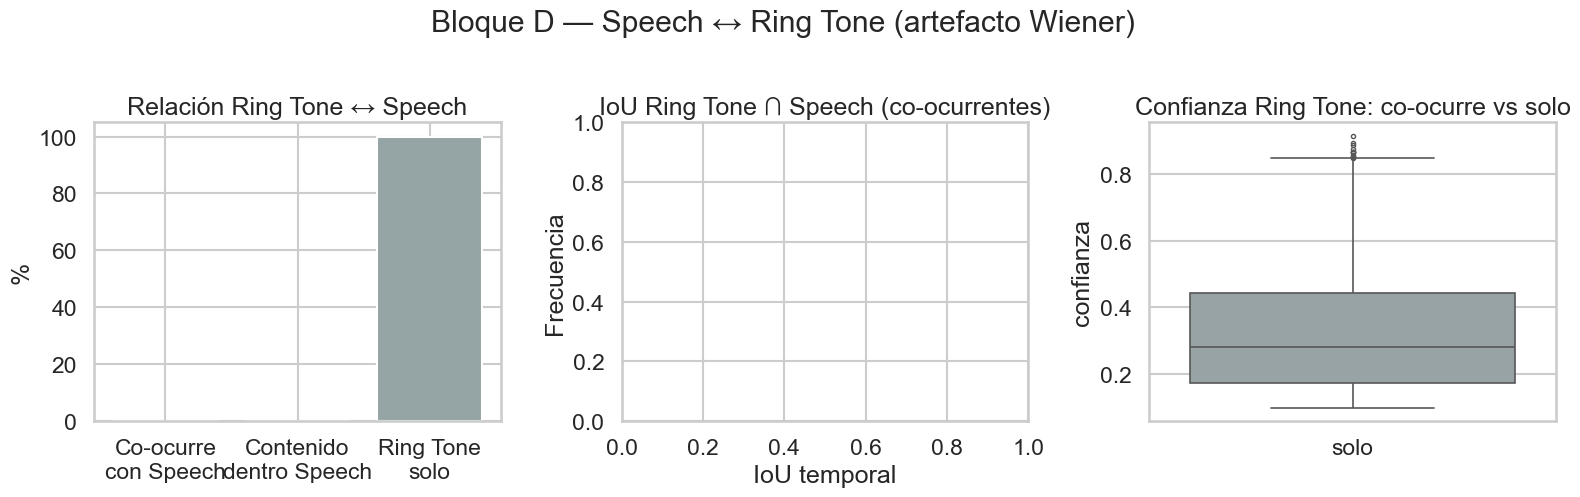


Regla propuesta: suprimir Ring Tone cuando 'inside_speech=True'
  Impacto: -0 detecciones Ring Tone (0.0% del total Ring Tone)


In [22]:
SPEECH_ID   = 4
RINGTONE_ID = 5

ring_rows = []
for tr, grp_tr in geo.groupby("trayecto"):
    speech_sub = grp_tr[grp_tr["class"] == SPEECH_ID]
    ring_sub   = grp_tr[grp_tr["class"] == RINGTONE_ID]
    if ring_sub.empty:
        continue
    # Speech intervals as numpy arrays (nanoseconds int64)
    sp_s = speech_sub.t_start.values.astype(np.int64) if not speech_sub.empty else np.empty(0, np.int64)
    sp_e = speech_sub.t_end.values.astype(np.int64)   if not speech_sub.empty else np.empty(0, np.int64)

    for _, r in ring_sub.iterrows():
        rs, re = r.t_start.value, r.t_end.value
        co_occurs = inside = False
        max_iou = 0.0
        if len(sp_s):
            inter = np.maximum(0, np.minimum(sp_e, re) - np.maximum(sp_s, rs))
            mask = inter > 0
            if mask.any():
                co_occurs = True
                dur_r = re - rs
                union = dur_r + (sp_e[mask] - sp_s[mask]) - inter[mask]
                iou_vals = inter[mask] / np.where(union > 0, union, 1)
                max_iou = float(iou_vals.max())
                inside  = bool(((sp_s[mask] <= rs) & (sp_e[mask] >= re)).any())
        ring_rows.append({
            "trayecto":        tr,
            "source":          r.source,
            "confidence":      r.confidence,
            "co_occurs_speech": co_occurs,
            "inside_speech":   inside,
            "max_iou":         round(max_iou, 3),
        })

ring_df = pd.DataFrame(ring_rows)
n_ring = len(ring_df)
n_co   = ring_df["co_occurs_speech"].sum()
n_in   = ring_df["inside_speech"].sum()

print(f"Ring Tone total: {n_ring}")
print(f"  Co-ocurre con Speech  : {n_co} ({n_co/n_ring*100:.1f}%)")
print(f"  Contenido dentro Speech: {n_in} ({n_in/n_ring*100:.1f}%)")

# IoU distribution when co-occurring
iou_co = ring_df.loc[ring_df["co_occurs_speech"], "max_iou"]
print(f"\n  IoU medio (co-ocurrentes): {iou_co.mean():.3f}  | mediana: {iou_co.median():.3f}")

# Confidence: co-occurring vs alone
conf_co   = ring_df.loc[ring_df["co_occurs_speech"],  "confidence"]
conf_solo = ring_df.loc[~ring_df["co_occurs_speech"], "confidence"]
from scipy.stats import mannwhitneyu
if len(conf_co) > 1 and len(conf_solo) > 1:
    stat, pval = mannwhitneyu(conf_co, conf_solo, alternative="two-sided")
    print(f"\nConfianza Ring Tone — co-ocurrente: {conf_co.mean():.3f}  |  solo: {conf_solo.mean():.3f}")
    print(f"Mann-Whitney U={stat:.0f}  p={pval:.4f}")

# Figura
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. % co-ocurrencia y % dentro
labels_ = ["Co-ocurre\ncon Speech", "Contenido\ndentro Speech", "Ring Tone\nsolo"]
vals_   = [n_co/n_ring, n_in/n_ring, (n_ring-n_co)/n_ring]
axes[0].bar(labels_, [v*100 for v in vals_], color=["#e74c3c","#c0392b","#95a5a6"])
axes[0].set_ylabel("%"); axes[0].set_title("Relación Ring Tone ↔ Speech")

# 2. IoU distribution
if len(iou_co):
    axes[1].hist(iou_co, bins=20, color="#e74c3c", edgecolor="white")
axes[1].set_xlabel("IoU temporal"); axes[1].set_ylabel("Frecuencia")
axes[1].set_title("IoU Ring Tone ∩ Speech (co-ocurrentes)")

# 3. Confidence co-occurring vs solo
conf_data = pd.concat([
    conf_co.rename("confianza").to_frame().assign(grupo="co-ocurre Speech"),
    conf_solo.rename("confianza").to_frame().assign(grupo="solo"),
])
sns.boxplot(data=conf_data, x="grupo", y="confianza",
            palette={"co-ocurre Speech":"#e74c3c","solo":"#95a5a6"},
            ax=axes[2], linewidth=1.2, fliersize=3)
axes[2].set_title("Confianza Ring Tone: co-ocurre vs solo")
axes[2].set_xlabel(""); axes[2].set_ylabel("confianza")

plt.suptitle("Bloque D — Speech ↔ Ring Tone (artefacto Wiener)", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/stat_speech_ringtone_artifact.png", dpi=130, bbox_inches="tight"); plt.show()

# Impacto: si se suprime Ring Tone cuando está contenido en Speech, ¿cuántos eventos desaparecen?
print(f"\nRegla propuesta: suprimir Ring Tone cuando 'inside_speech=True'")
print(f"  Impacto: -{n_in} detecciones Ring Tone ({n_in/n_ring*100:.1f}% del total Ring Tone)")

## Resumen estadístico — tabla maestra por clase

In [23]:
master = conf_tab.copy().rename(columns={"mean":"conf_mean","std":"conf_std",
                                            "p25":"conf_p25","median":"conf_med","p75":"conf_p75"})
dur2 = (geo.groupby("class_name")["duration_s"]
           .agg(dur_mean="mean", dur_std="std", dur_median="median").loc[CLASS_ORDER])
rate2 = rates.groupby("class_name")[["per_min","per_km"]].mean().loc[CLASS_ORDER].round(3)
master = master.join(dur2).join(rate2)
master.index.name = "clase"
display(master)
master.to_csv("../outputs/stat_master_by_class.csv")
print("guardado outputs/stat_master_by_class.csv")

,n,conf_mean,conf_std,conf_p25,conf_med,conf_p75,dur_mean,dur_std,dur_median,per_min,per_km
clase,,,,,,,,,,,
Horn,475,0.292,0.202,0.139,0.206,0.403,2.391390,1.701576,2.299038,0.723,1.050
Siren,41,0.325,0.196,0.157,0.274,0.479,4.001214,2.927922,2.237767,0.115,0.165
Pets,994,0.256,0.163,0.133,0.193,0.323,1.015640,1.370483,0.346417,1.570,2.203
Physiological,2043,0.276,0.176,0.142,0.214,0.360,1.659121,1.535429,1.119848,3.279,4.508
Speech,2676,0.476,0.258,0.221,0.471,0.713,5.920801,2.234020,7.353177,7.345,11.171
Ring Tone,3497,0.324,0.179,0.172,0.281,0.443,6.309954,1.564501,7.023834,5.848,7.691
Vibrating,3190,0.385,0.247,0.167,0.309,0.570,1.945357,0.582517,2.064221,7.162,9.735
Notifications,34,0.283,0.186,0.129,0.229,0.397,1.014015,1.148488,0.547570,0.117,0.175
Cry,91,0.256,0.138,0.139,0.218,0.352,5.955387,1.603332,6.337606,0.312,0.461


guardado outputs/stat_master_by_class.csv
